# Lab 9 — Bias, Variance, and the Bias–Variance Tradeoff

## Instructor copy

This lab follows the ideas and sequence of **AML Lecture 9**. It begins with a controlled experiment in which the true function is known. It then moves to a real dataset, where the true function is not known and we must diagnose model behaviour using validation error, cross-validation, and learning curves.

`bias_variance_tools.py` now holds only the reusable *plumbing*: fitting/predicting a polynomial model and loading/splitting the real dataset. The actual lesson — drawing repeated samples, estimating bias and variance, cross-validation, learning curves — is written directly in the notebook, one step at a time, so the logic behind each result is visible rather than hidden in a helper function.

## Learning outcomes

By the end of this lab, students should be able to:

1. explain the model $Y=f(X)+\varepsilon$;
2. explain why different training samples produce different fitted models;
3. identify high bias, high variance, underfitting, and overfitting;
4. use $\text{MSE}=\text{Bias}^2+\text{Variance}+\text{Irreducible Error}$ in a controlled simulation;
5. keep training, validation, and test data separate;
6. use cross-validation and learning curves to diagnose a regression model.

## 1. Setup

The values below are fixed teaching settings. Stating them here makes the experiment reproducible; they are not properties of every regression problem.

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

import bias_variance_tools as bvt
importlib.reload(bvt)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_SEED = 42
NOISE_STANDARD_DEVIATION = 20
SAMPLE_SIZE = 20

print("Lab settings loaded.")

Lab settings loaded.


# Part A — Controlled experiment: the true function is known

## 2. Start with $Y=f(X)+\varepsilon$

For this experiment:

$$f(x)=x^2$$

and

$$Y=f(X)+\varepsilon.$$

- $f(X)$ is the true pattern.
- $Y$ is the observed output.
- $\varepsilon$ is random noise that the model cannot predict.

The population contains 100 evenly spaced input values between $-15$ and $10$. We add normally distributed noise with mean 0 and standard deviation 20. These choices are visible lab settings so that students know exactly how the data were made.

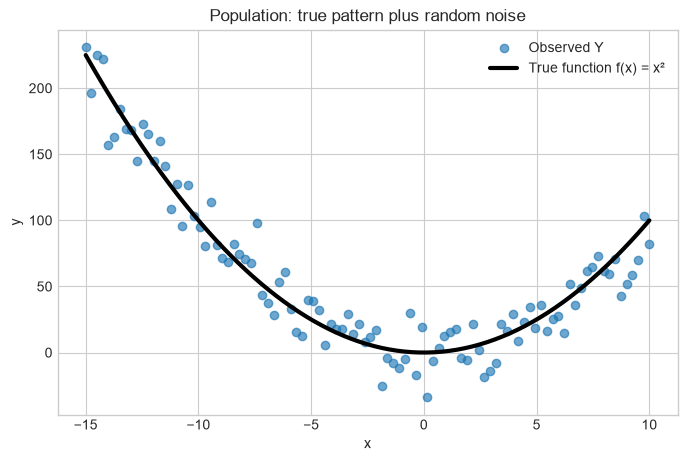

In [2]:
def true_function(x):
    """The hidden pattern we are trying to learn: f(x) = x^2."""
    # Convert the input values to numbers and calculate the square of each value (x²).
    # This creates the polynomial feature needed for a degree-2 polynomial model.
    return x ** 2

number_of_points = 100
x_population = np.linspace(-15, 10, number_of_points)

rng = np.random.default_rng(RANDOM_SEED)
noise = rng.normal(0, NOISE_STANDARD_DEVIATION, number_of_points)
# Generate the target values by adding random noise to the true function values.
# This simulates real-world data, where observations usually contain some noise
# or random variation around the underlying true relationship.
y_population = true_function(x_population) + noise
x_grid = np.linspace(-15, 10, 300)

plt.scatter(x_population, y_population, alpha=0.65, label="Observed Y")
plt.plot(x_grid, true_function(x_grid), color="black", linewidth=3,
         label="True function f(x) = x²")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Population: true pattern plus random noise")
plt.legend()
plt.show()

The black curve is available only because we created the data ourselves. With real data, the true $f(x)$ is normally unknown.

## 3. One estimator, different training samples

An estimator is a learning rule. The fitted result, $\hat f(x)$, changes when the training sample changes. We demonstrate this by drawing three samples from the same population.

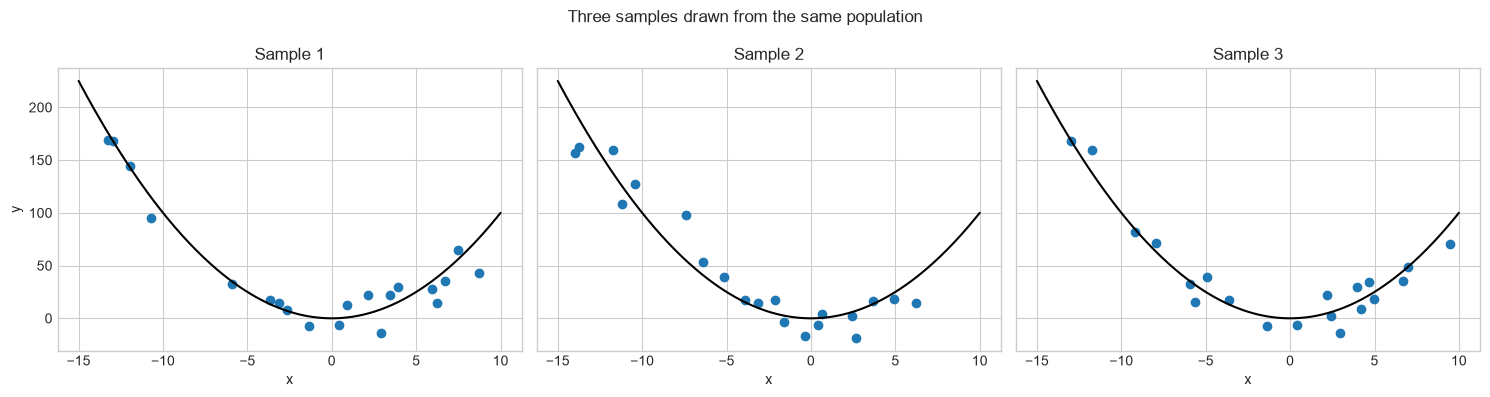

In [3]:
def draw_samples(x_population, y_population, number_of_samples, sample_size, seed):
    """Draw several independent samples of the same size from one population."""
    rng = np.random.default_rng(seed)
    samples = []

    for _ in range(number_of_samples):
        chosen_rows = rng.choice(len(x_population), size=sample_size, replace=False)
        samples.append({
            "x": np.asarray(x_population)[chosen_rows],
            "y": np.asarray(y_population)[chosen_rows],
        })

    return samples


samples = draw_samples(
    x_population, y_population,
    number_of_samples=3, sample_size=SAMPLE_SIZE, seed=RANDOM_SEED,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for sample_number, sample in enumerate(samples):
    axes[sample_number].scatter(sample["x"], sample["y"], color="tab:blue")
    axes[sample_number].plot(x_grid, true_function(x_grid), color="black")
    axes[sample_number].set_title("Sample " + str(sample_number + 1))
    axes[sample_number].set_xlabel("x")

axes[0].set_ylabel("y")
plt.suptitle("Three samples drawn from the same population")
plt.tight_layout()
plt.show()

## 4. Fit a straight line to each sample

A degree-1 model is a straight line. The true pattern is curved, so a straight line is too simple for this problem.

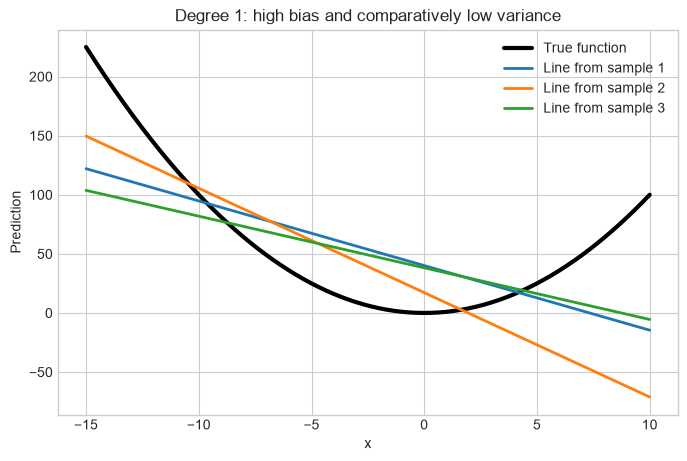

In [4]:
def fit_models_to_samples(samples, degree, x_minimum, x_maximum):
    """Fit one polynomial model of the given degree to each sample."""
    return [
        bvt.fit_polynomial_model(sample["x"], sample["y"], degree, x_minimum, x_maximum)
        for sample in samples
    ]


linear_models = fit_models_to_samples(samples, degree=1, x_minimum=-15, x_maximum=10)

plt.plot(x_grid, true_function(x_grid), color="black", linewidth=3,
         label="True function")

for model_number, model in enumerate(linear_models):
    predictions = bvt.predict_polynomial(model, x_grid)
    plt.plot(x_grid, predictions, linewidth=2,
             label="Line from sample " + str(model_number + 1))

plt.xlabel("x")
plt.ylabel("Prediction")
plt.title("Degree 1: high bias and comparatively low variance")
plt.legend()
plt.show()

> **Instructor interpretation:** The three lines are fairly similar to one another, but none can reproduce the curved true function. This is the expected **high-bias, low-variance** pattern. The model **underfits**.

## 5. Fit a very flexible polynomial to each sample

A degree-5 polynomial is much more flexible than the true degree-2 pattern. It can follow a small sample closely, including some of its random noise.

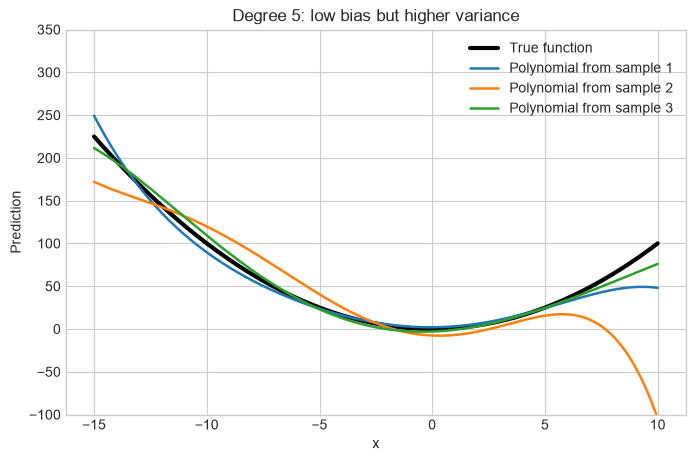

In [5]:
flexible_models = fit_models_to_samples(samples, degree=5, x_minimum=-15, x_maximum=10)

plt.plot(x_grid, true_function(x_grid), color="black", linewidth=3,
         label="True function")

for model_number, model in enumerate(flexible_models):
    predictions = bvt.predict_polynomial(model, x_grid)
    plt.plot(x_grid, predictions, linewidth=1.8,
             label="Polynomial from sample " + str(model_number + 1))

plt.ylim(-100, 350)
plt.xlabel("x")
plt.ylabel("Prediction")
plt.title("Degree 5: low bias but higher variance")
plt.legend()
plt.show()

> **Instructor interpretation:** The flexible curves can follow the quadratic shape, so their bias can be low. However, their shapes change sharply across samples because they also react to noise. This is the expected **low-bias, high-variance** pattern. The model **overfits**.

| Model behaviour | Bias | Variance | Usual result |
|---|---:|---:|---|
| Too simple | High | Low | Underfitting |
| Suitable complexity | Moderate/low | Moderate/low | Better generalisation |
| Too flexible | Low | High | Overfitting |

## 6. Bias and variance at one input value

At a fixed input $x$:

$$\text{Bias}(x)=E[\hat f(x)]-f(x)$$

Bias measures how far the average prediction is from the truth.

$$\text{Variance}(x)=E[(\hat f(x)-E[\hat f(x)])^2]$$

Variance measures how much predictions change across different training samples.

The next cell trains 100 models for each degree and compares their predictions at $x=5$. Since $f(5)=25$, the true value is known.

In [6]:
def collect_repeated_predictions(degree, x_values, number_of_models, sample_size,
                                  noise_standard_deviation, seed):
    """
    Simulate many training datasets from the same population, fit a model of
    the given degree to each one, and record every model's prediction at
    x_values. Repeating this many times is how we approximate E[f_hat(x)]
    and Var(f_hat(x)) -- quantities that normally require infinitely many
    datasets we don't actually have.
    """
    rng = np.random.default_rng(seed)
    all_predictions = []

    for _ in range(number_of_models):
        sample_x = rng.uniform(-15, 10, sample_size)
        sample_noise = rng.normal(0, noise_standard_deviation, sample_size)
        sample_y = true_function(sample_x) + sample_noise

        model = bvt.fit_polynomial_model(sample_x, sample_y, degree, -15, 10)
        predictions = bvt.predict_polynomial(model, x_values)
        all_predictions.append(predictions)

    return np.asarray(all_predictions)


def prediction_summary(predictions, true_value, noise_variance):
    """Turn repeated predictions at one point into a bias-variance decomposition."""
    predictions = np.asarray(predictions, dtype=float).reshape(-1)
    mean_prediction = predictions.mean()
    bias = mean_prediction - true_value
    variance = predictions.var()

    return {
        "Mean prediction": mean_prediction,
        "Bias": bias,
        "Bias squared": bias**2,
        "Variance": variance,
        "Irreducible noise": noise_variance,
        "Estimated MSE": bias**2 + variance + noise_variance,
    }


query_x = 5
summary_rows = []

for degree in [1, 2, 5]:
    repeated_predictions = collect_repeated_predictions(
        degree=degree,
        x_values=[query_x],
        number_of_models=100,
        sample_size=SAMPLE_SIZE,
        noise_standard_deviation=NOISE_STANDARD_DEVIATION,
        seed=RANDOM_SEED,
    )
    summary = prediction_summary(
        repeated_predictions,
        true_value=true_function(query_x),
        noise_variance=NOISE_STANDARD_DEVIATION**2,
    )
    summary["Degree"] = degree
    summary_rows.append(summary)

point_results = pd.DataFrame(summary_rows)
point_results = point_results[[
    "Degree", "Mean prediction", "Bias", "Bias squared", "Variance",
    "Irreducible noise", "Estimated MSE"
]]
display(point_results.round(2))

,Degree,Mean prediction,Bias,Bias squared,Variance,Irreducible noise,Estimated MSE
0,1,19.15,-5.85,34.22,312.57,400,746.79
1,2,23.05,-1.95,3.82,47.74,400,451.55
2,5,21.80,-3.20,10.21,224.04,400,634.25


## 7. MSE decomposition

For squared-error regression, the expected prediction error can be written as:

$$\text{MSE}=\text{Bias}^2+\text{Variance}+\text{Var}(\varepsilon)$$

The last term is the **irreducible error**. More flexible modelling cannot remove randomness already present in the data.

### Worked check from the lecture

If the average prediction is 12 and the true value is 10:

$$\text{Bias}=12-10=2.$$

If bias is 2, variance is 3, and noise variance is 1:

$$\text{MSE}=2^2+3+1=8.$$

In [7]:
worked_bias = 12 - 10
worked_mse = worked_bias**2 + 3 + 1

print("Bias:", worked_bias)
print("MSE:", worked_mse)

Bias: 2
MSE: 8


## 8. Observe the bias–variance tradeoff

The next simulation averages results over the full input range. It is a numerical estimate from repeated samples, not an exact symbolic calculation.

In [8]:
def bias_variance_table(degrees, x_values, number_of_models, sample_size,
                         noise_standard_deviation, seed):
    """Estimate the bias-variance decomposition for several model degrees at once."""
    x_values = np.asarray(x_values, dtype=float).reshape(-1)
    correct_values = true_function(x_values)
    rows = []

    for degree in degrees:
        predictions = collect_repeated_predictions(
            degree, x_values, number_of_models, sample_size,
            noise_standard_deviation, seed,
        )
        mean_prediction = predictions.mean(axis=0)
        bias_squared = np.mean((mean_prediction - correct_values) ** 2)
        variance = np.mean(predictions.var(axis=0))
        noise_variance = noise_standard_deviation**2

        rows.append({
            "Degree": degree,
            "Bias_squared": bias_squared,
            "Variance": variance,
            "Irreducible_noise": noise_variance,
            "Estimated_MSE": bias_squared + variance + noise_variance,
        })

    return pd.DataFrame(rows)


degrees_for_simulation = [1, 2, 3, 4, 5, 6]

bias_variance_results = bias_variance_table(
    degrees=degrees_for_simulation,
    x_values=x_grid,
    number_of_models=100,
    sample_size=SAMPLE_SIZE,
    noise_standard_deviation=NOISE_STANDARD_DEVIATION,
    seed=RANDOM_SEED,
)

display(bias_variance_results.round(2))

,Degree,Bias_squared,Variance,Irreducible_noise,Estimated_MSE
0,1,2203.62,393.88,400,2997.50
1,2,1.84,76.33,400,478.17
2,3,2.92,122.81,400,525.73
3,4,5.85,334.56,400,740.41
4,5,3.85,869.59,400,1273.44
5,6,58.48,4352.79,400,4811.26


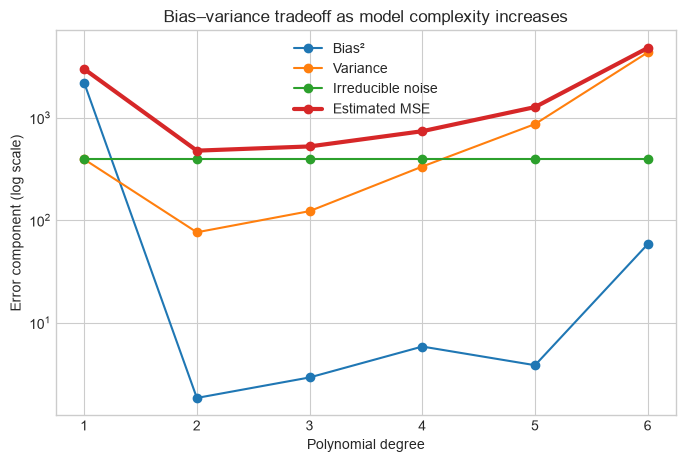

In [9]:
plt.plot(bias_variance_results["Degree"],
         bias_variance_results["Bias_squared"], marker="o", label="Bias²")
plt.plot(bias_variance_results["Degree"],
         bias_variance_results["Variance"], marker="o", label="Variance")
plt.plot(bias_variance_results["Degree"],
         bias_variance_results["Irreducible_noise"], marker="o",
         label="Irreducible noise")
plt.plot(bias_variance_results["Degree"],
         bias_variance_results["Estimated_MSE"], marker="o", linewidth=3,
         label="Estimated MSE")

plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("Error component (log scale)")
plt.title("Bias–variance tradeoff as model complexity increases")
plt.legend()
plt.show()

> **Instructor interpretation:** Degree 1 cannot represent the quadratic pattern, so it has high bias. Degree 2 matches the true family and normally gives the best balance here. Very high degrees react strongly to the training sample, so variance increases. The y-axis is logarithmic because the most flexible models can produce errors much larger than the other models.

# Part B — Real data: the true function is unknown

## 9. From theory to diagnosis

In a real problem we usually have one dataset, not every possible sample from the population. We also do not know the true $f(x)$. Therefore, we normally cannot calculate exact mathematical bias and variance.

Instead, we diagnose model behaviour with:

- training and validation error;
- a train/validation/test split;
- cross-validation;
- learning curves.

For the applied section, we predict `Exam_Score` from `Study_Hours`. This is a one-input regression example so that model complexity remains easy to plot.

In [10]:
data_file = Path("academic_outcomes.csv")
if not data_file.exists():
    data_file = Path("Lab_9/Instructor/academic_outcomes.csv")

academic_data = bvt.load_academic_data(data_file)

print("Rows:", academic_data.shape[0])
print("Columns:", academic_data.shape[1])
display(academic_data[["Study_Hours", "Exam_Score"]].head())
display(academic_data[["Study_Hours", "Exam_Score"]].describe().round(2))

Rows: 300
Columns: 12


,Study_Hours,Exam_Score
0,3,60
1,1,44
2,3,46
3,5,51
4,5,54


,Study_Hours,Exam_Score
count,300.00,300.00
mean,5.22,63.21
std,2.18,18.14
min,0.00,14.00
25%,4.00,50.75
50%,5.00,64.00
75%,7.00,76.00
max,10.00,100.00


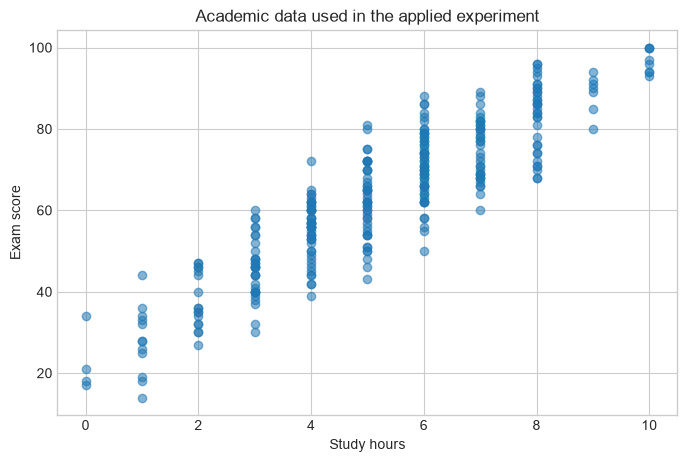

In [11]:
plt.scatter(academic_data["Study_Hours"], academic_data["Exam_Score"],
            alpha=0.55)
plt.xlabel("Study hours")
plt.ylabel("Exam score")
plt.title("Academic data used in the applied experiment")
plt.show()

## 10. Training, validation, and test data

- **Training set:** fits the model parameters.
- **Validation set:** compares model degrees and helps choose one.
- **Test set:** gives one final estimate after all choices are complete.

The helper makes a reproducible 60%/20%/20% split. We do not inspect test error while choosing the degree.

In [12]:
data_split = bvt.split_regression_data(academic_data, seed=RANDOM_SEED)

split_sizes = pd.Series({
    "Training rows": len(data_split["x_train"]),
    "Validation rows": len(data_split["x_validation"]),
    "Test rows": len(data_split["x_test"]),
})
display(split_sizes.to_frame("Count"))

,Count
Training rows,180
Validation rows,60
Test rows,60


## 11. Compare model complexity

Training MSE almost always falls, or stays the same, when complexity increases. Validation MSE tells us whether the extra flexibility helps on unseen data.

In [13]:
def model_complexity_errors(x_train, y_train, x_validation, y_validation, degrees):
    """Fit each polynomial degree on the training set and record train/validation MSE."""
    rows = []

    for degree in degrees:
        model = bvt.fit_polynomial_model(x_train, y_train, degree)
        train_predictions = bvt.predict_polynomial(model, x_train)
        validation_predictions = bvt.predict_polynomial(model, x_validation)

        rows.append({
            "Degree": degree,
            "Train_MSE": mean_squared_error(y_train, train_predictions),
            "Validation_MSE": mean_squared_error(y_validation, validation_predictions),
        })

    return pd.DataFrame(rows)


degrees_to_compare = list(range(1, 11))

complexity_results = model_complexity_errors(
    data_split["x_train"],
    data_split["y_train"],
    data_split["x_validation"],
    data_split["y_validation"],
    degrees_to_compare,
)

display(complexity_results.round(2))

,Degree,Train_MSE,Validation_MSE
0,1,56.31,65.58
1,2,55.26,64.56
2,3,55.10,65.34
3,4,54.44,66.22
4,5,54.44,66.35
5,6,54.43,66.47
6,7,54.43,66.51
7,8,54.25,66.04
8,9,54.03,66.07
9,10,52.86,68.18


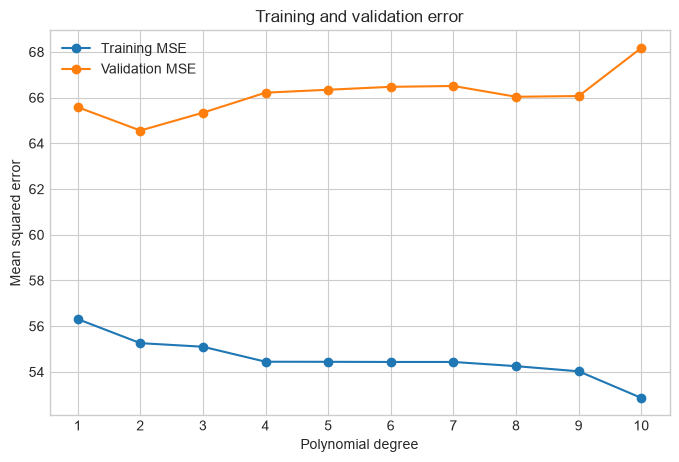

Degree selected by this validation split: 2


In [14]:
plt.plot(complexity_results["Degree"], complexity_results["Train_MSE"],
         marker="o", label="Training MSE")
plt.plot(complexity_results["Degree"], complexity_results["Validation_MSE"],
         marker="o", label="Validation MSE")
plt.xlabel("Polynomial degree")
plt.ylabel("Mean squared error")
plt.title("Training and validation error")
plt.xticks(degrees_to_compare)
plt.legend()
plt.show()

best_validation_row = complexity_results["Validation_MSE"].idxmin()
best_validation_degree = int(complexity_results.loc[best_validation_row, "Degree"])
print("Degree selected by this validation split:", best_validation_degree)

### Reading the error pattern

- **High bias:** training and validation errors are both high and close together.
- **High variance:** training error is low, but validation error is much higher.
- **Better balance:** validation error is low and the train–validation gap is not excessive.

> **Instructor note:** Exact words such as “high” and “low” are relative to the task. Ask students to compare models on the same dataset and metric rather than inventing a universal MSE cutoff.

## 12. Cross-validation checks stability

One validation result depends on one split. Five-fold cross-validation repeats the train/validation process across five folds. The mean CV MSE measures average error; the standard deviation shows how much that error changes across folds.

In [15]:
def cross_validation_errors(x, y, degrees, number_of_folds, seed):
    """Estimate the mean and spread of validation MSE across K folds."""
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    folds = KFold(n_splits=number_of_folds, shuffle=True, random_state=seed)
    rows = []

    for degree in degrees:
        fold_errors = []

        for train_rows, validation_rows in folds.split(x):
            model = bvt.fit_polynomial_model(x[train_rows], y[train_rows], degree)
            predictions = bvt.predict_polynomial(model, x[validation_rows])
            fold_errors.append(mean_squared_error(y[validation_rows], predictions))

        rows.append({
            "Degree": degree,
            "Mean_CV_MSE": np.mean(fold_errors),
            "Std_CV_MSE": np.std(fold_errors),
        })

    return pd.DataFrame(rows)


x_development = np.concatenate([
    data_split["x_train"], data_split["x_validation"]
])
y_development = np.concatenate([
    data_split["y_train"], data_split["y_validation"]
])

cv_results = cross_validation_errors(
    x=x_development,
    y=y_development,
    degrees=degrees_to_compare,
    number_of_folds=5,
    seed=RANDOM_SEED,
)

display(cv_results.round(2))

best_cv_row = cv_results["Mean_CV_MSE"].idxmin()
chosen_degree = int(cv_results.loc[best_cv_row, "Degree"])
print("Degree selected by 5-fold cross-validation:", chosen_degree)

,Degree,Mean_CV_MSE,Std_CV_MSE
0,1,59.27,4.58
1,2,58.53,3.10
2,3,59.53,3.23
3,4,59.66,3.57
4,5,60.23,3.30
5,6,60.72,3.40
6,7,60.70,3.41
7,8,60.98,4.41
8,9,60.87,4.45
9,10,60.74,4.34


Degree selected by 5-fold cross-validation: 2


## 13. Learning curves

A learning curve shows training and validation error as the amount of training data grows.

- **High-bias pattern:** both errors remain high and close together.
- **High-variance pattern:** training error is much lower than validation error. More representative data may reduce the gap.

We compare a simple degree-1 model and a flexible degree-10 model. These labels describe their complexity; the actual error curves determine the diagnosis.

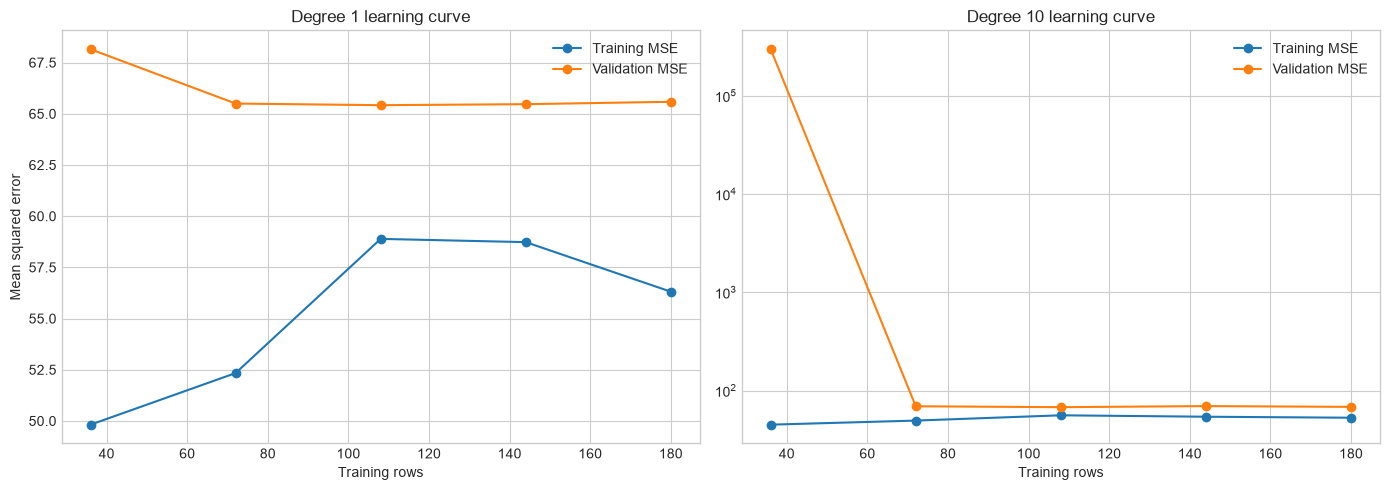

In [16]:
def learning_curve_errors(x_train, y_train, x_validation, y_validation, degree,
                           training_fractions=None, seed=42):
    """Measure train/validation MSE as the amount of training data increases."""
    if training_fractions is None:
        training_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

    x_train = np.asarray(x_train, dtype=float).reshape(-1)
    y_train = np.asarray(y_train, dtype=float).reshape(-1)
    rng = np.random.default_rng(seed)
    shuffled_rows = rng.permutation(len(x_train))
    x_shuffled = x_train[shuffled_rows]
    y_shuffled = y_train[shuffled_rows]
    rows = []

    for fraction in training_fractions:
        training_size = max(2, int(len(x_train) * fraction))
        x_small = x_shuffled[:training_size]
        y_small = y_shuffled[:training_size]

        model = bvt.fit_polynomial_model(x_small, y_small, degree)
        train_predictions = bvt.predict_polynomial(model, x_small)
        validation_predictions = bvt.predict_polynomial(model, x_validation)

        rows.append({
            "Training_Size": training_size,
            "Train_MSE": mean_squared_error(y_small, train_predictions),
            "Validation_MSE": mean_squared_error(y_validation, validation_predictions),
        })

    return pd.DataFrame(rows)


simple_curve = learning_curve_errors(
    data_split["x_train"], data_split["y_train"],
    data_split["x_validation"], data_split["y_validation"],
    degree=1, seed=RANDOM_SEED
)

flexible_curve = learning_curve_errors(
    data_split["x_train"], data_split["y_train"],
    data_split["x_validation"], data_split["y_validation"],
    degree=10, seed=RANDOM_SEED
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(simple_curve["Training_Size"], simple_curve["Train_MSE"],
             marker="o", label="Training MSE")
axes[0].plot(simple_curve["Training_Size"], simple_curve["Validation_MSE"],
             marker="o", label="Validation MSE")
axes[0].set_title("Degree 1 learning curve")
axes[0].set_xlabel("Training rows")
axes[0].set_ylabel("Mean squared error")
axes[0].legend()

axes[1].plot(flexible_curve["Training_Size"], flexible_curve["Train_MSE"],
             marker="o", label="Training MSE")
axes[1].plot(flexible_curve["Training_Size"], flexible_curve["Validation_MSE"],
             marker="o", label="Validation MSE")
axes[1].set_title("Degree 10 learning curve")
axes[1].set_xlabel("Training rows")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

> **Instructor discussion:** Ask students to describe the gap between the two curves before naming the problem. A large persistent gap supports a high-variance diagnosis. Two relatively high curves that meet support a high-bias diagnosis. Adding data is most likely to help when variance is the main problem. The degree-10 panel uses a logarithmic y-axis because its error with the smallest training subset is much larger.

## 14. Final test evaluation

The degree has now been selected without using the test set. We refit that degree using the combined training and validation rows, then use the test set once. Degree 1 is also reported as a simple reference model.

In [17]:
def final_test_error(data_split, degree):
    """Refit on training+validation data, then evaluate once on the held-out test set."""
    x_final_train = np.concatenate(
        [data_split["x_train"], data_split["x_validation"]]
    )
    y_final_train = np.concatenate(
        [data_split["y_train"], data_split["y_validation"]]
    )

    model = bvt.fit_polynomial_model(x_final_train, y_final_train, degree)
    test_predictions = bvt.predict_polynomial(model, data_split["x_test"])
    return mean_squared_error(data_split["y_test"], test_predictions)


final_results = pd.DataFrame({
    "Model": ["Degree 1 reference", "Cross-validation choice"],
    "Degree": [1, chosen_degree],
    "Test_MSE": [
        final_test_error(data_split, degree=1),
        final_test_error(data_split, degree=chosen_degree),
    ],
})

display(final_results.round(2))

,Model,Degree,Test_MSE
0,Degree 1 reference,1,68.88
1,Cross-validation choice,2,65.94


# Instructor practice and answer key

## A. Concept check

| Situation | Answer |
|---|---|
| Model predictions are consistently away from the truth | High bias |
| Model predictions change greatly across samples | High variance |
| Model is too simple to learn the pattern | Underfitting |
| Model follows training noise | Overfitting |
| Error caused by random noise | Irreducible error |

## B. Short calculations

1. If $E[\hat f(x)]=12$ and $f(x)=10$, the bias is **2**.
2. If bias is 2, variance is 3, and noise variance is 1, the expected MSE is **8**.
3. If irreducible error increases while bias and variance stay fixed, total expected MSE **increases by the same amount**.

## C. Diagnosis

1. Training and validation errors are both high and close: **likely high bias / underfitting**.
2. Training error is low but validation error is much higher: **likely high variance / overfitting**.
3. Error changes greatly across CV folds: **the result is unstable across splits**.
4. A flexible model has a large learning-curve gap: **more representative training data may help**.

# Lab 9 summary

- Different samples produce different fitted models.
- Simple models tend toward higher bias and lower variance.
- Very flexible models tend toward lower bias and higher variance.
- Expected MSE contains bias squared, variance, and irreducible error.
- In real data, diagnose behaviour with train/validation results, cross-validation, and learning curves.
- Keep the test set untouched until the model choice is finished.